# Implementacja drzewa czwórkowego (quadtree)

In [60]:
from visualizer.main import Visualizer
import numpy

In [2]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"Point({self.x}, {self.y})"

In [17]:
class Boundary:
    def __init__(self, ld: Point, rd: Point, ru: Point, lu: Point):
        self.left_down = ld
        self.right_down = rd
        self.right_up = ru
        self.left_up = lu

    def contains(self, p: Point) -> bool:
        return self.left_down.x <= p.x <= self.right_up.x and self.left_down.y <= p.y <= self.right_up.y

    def to_list(self):
        return [(self.left_down.x, self.left_down.y),
                (self.right_down.x, self.right_down.y),
                (self.right_up.x, self.right_up.y),
                (self.left_up.x, self.left_up.y)]

In [88]:
def visualize_boundary(boundary: Boundary, vis=None) -> Visualizer:
    if not vis:
        vis = Visualizer()

    t = boundary.to_list()

    for i in range(len(t)):
        segment = (t[i], t[(i + 1) % len(t)])
        vis.add_line_segment(segment, color='green', linewidths=0.5)

    return vis

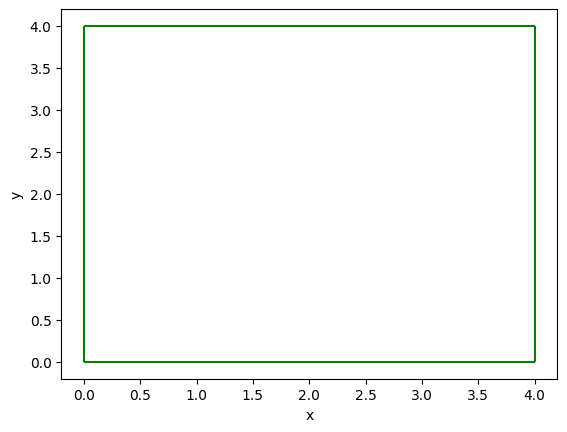

In [29]:
bound = Boundary(Point(0, 0), Point(4, 0), Point(4, 4), Point(0, 4))
vis = visualize_boundary(bound)
vis.show()


In [45]:
points = [Point(1, 1), Point(2.1, 2.2), Point(3.52542, 3.1245), Point(0.5, 3.5), Point(3.8, 0.2)]

In [133]:
class Quadtree:
    def __init__(self, boundary: Boundary, capacity: int = 1):
        self.boundary = boundary
        self.capacity = capacity
        self.points = []

        self.left_down = None
        self.right_down = None
        self.right_up = None
        self.left_up = None

    def subdivide(self):
        mid_x = (self.boundary.left_down.x + self.boundary.right_up.x) / 2
        mid_y = (self.boundary.left_down.y + self.boundary.right_up.y) / 2

        self.left_down = Quadtree(Boundary(
            self.boundary.left_down,
            Point(mid_x, self.boundary.left_down.y),
            Point(mid_x, mid_y),
            Point(self.boundary.left_down.x, mid_y)
        ))

        self.right_down = Quadtree(Boundary(
            Point(mid_x, self.boundary.left_down.y),
            self.boundary.right_down,
            Point(self.boundary.right_up.x, mid_y),
            Point(mid_x, mid_y)
        ))

        self.right_up = Quadtree(Boundary(
            Point(mid_x, mid_y),
            Point(self.boundary.right_up.x, mid_y),
            self.boundary.right_up,
            Point(mid_x, self.boundary.left_up.y)
        ))

        self.left_up =  Quadtree(Boundary(
            Point(self.boundary.left_down.x, mid_y),
            Point(mid_x, mid_y),
            Point(mid_x, self.boundary.left_up.y),
            self.boundary.left_up
        ))

    def insert(self, point: list[Point] | Point) -> bool:
        if isinstance(point, list):
            return all(self.insert(p) for p in point)

        if not self.boundary.contains(point):
            return False

        if self.left_down is None:
            if self.capacity > 0:
                self.capacity -= 1
                self.points.append(point)
                return True
            else:
                self.subdivide()

                for p in self.points:
                    self._insert_to_all(p)

                self.points = []

        return self._insert_to_all(point)

    def _insert_to_all(self, point: Point) -> bool:
        # added = False
        #
        # if not added and self.left_down.insert(point):
        #     added = True
        # elif not added and self.right_down.insert(point):
        #     added = True
        # elif not added and self.right_up.insert(point):
        #     added = True
        # elif not added and self.left_up.insert(point):
        #     added = True
        #
        # return added
        # ten sam kod, python i tak kończy sprawdzanie po znalezieniu pierwszego True

        return (self.left_down.insert(point) or self.right_down.insert(point) or
                self.right_up.insert(point) or self.left_up.insert(point))


    def get_points(self) -> list[Point]:
        result = self.points.copy()

        if self.left_down:
            result.extend(self.left_down.get_points())
        if self.right_down:
            result.extend(self.right_down.get_points())
        if self.right_up:
            result.extend(self.right_up.get_points())
        if self.left_up:
            result.extend(self.left_up.get_points())

        return result

In [84]:
def visualize_quadtree(quadtree: Quadtree, points: list[Point], vis=None) -> Visualizer:
    if not vis:
        vis = Visualizer()

    vis = visualize_boundary(quadtree.boundary, vis)

    for p in points:
        quadtree.insert(p)

    def visualize_subtree(qt: Quadtree):
        nonlocal vis
        if qt.left_down:
            vis = visualize_boundary(qt.left_down.boundary, vis)
            visualize_subtree(qt.left_down)
        if qt.right_down:
            vis = visualize_boundary(qt.right_down.boundary, vis)
            visualize_subtree(qt.right_down)
        if qt.right_up:
            vis = visualize_boundary(qt.right_up.boundary, vis)
            visualize_subtree(qt.right_up)
        if qt.left_up:
            vis = visualize_boundary(qt.left_up.boundary, vis)
            visualize_subtree(qt.left_up)

    visualize_subtree(quadtree)

    for p in points:
        vis.add_point((p.x, p.y), color='red')

    return vis

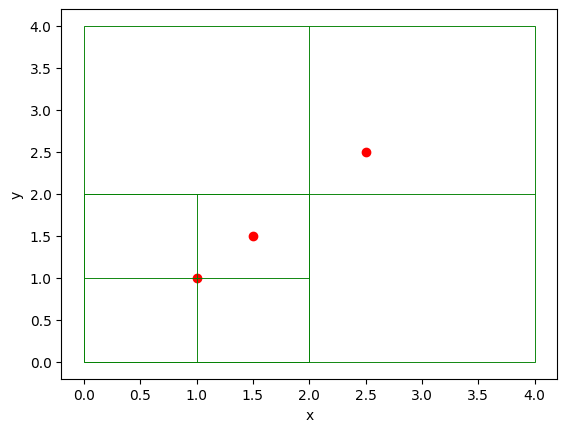

In [132]:
tree = Quadtree(bound)
vis = visualize_quadtree(tree, points)
vis.show()

In [74]:
def generate_random_points(boundary: Boundary, n: int) -> list[Point]:
    points = []
    for _ in range(n):
        x = numpy.random.uniform(boundary.left_down.x, boundary.right_up.x)
        y = numpy.random.uniform(boundary.left_down.y, boundary.right_up.y)
        points.append(Point(x, y))
    return points

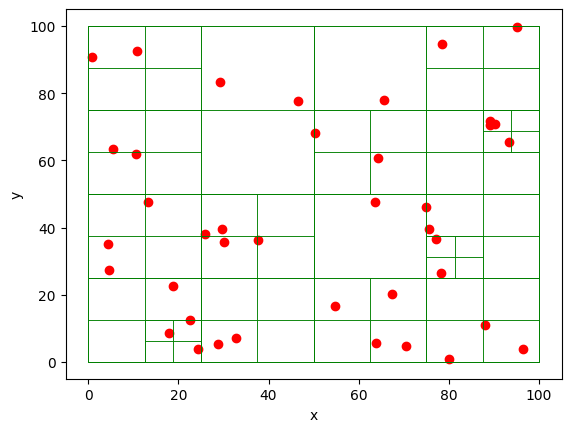

In [135]:
test_bound = Boundary(Point(0, 0), Point(100, 0), Point(100, 100), Point(0, 100))
random_points = generate_random_points(test_bound, 40)
test_tree = Quadtree(test_bound)
test_vis = visualize_quadtree(test_tree, random_points)
test_vis.show()


[Point(2.5, 2.5)]


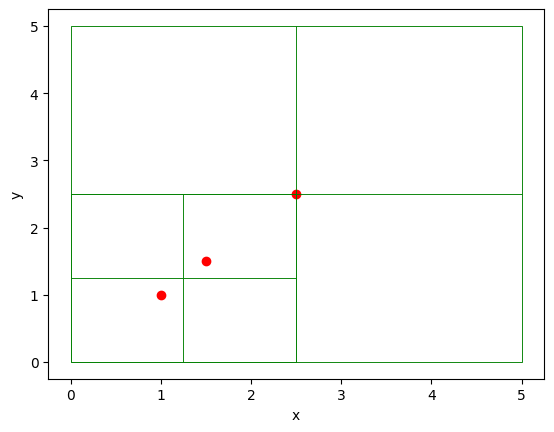

In [134]:
test_bound = Boundary(Point(0, 0), Point(5, 0), Point(5, 5), Point(0, 5))
points = [Point(1,1), Point(1.5,1.5), Point(2.5, 2.5)]
test_tree = Quadtree(test_bound)
test_vis = visualize_quadtree(test_tree, points)
test_vis.show()

print(test_tree.get_points())